In [1]:
!nvidia-smi


Tue Sep 22 08:33:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   68C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# 1. Cài đặt thư viện kaggle
!pip install -q kaggle

# 2. Chọn và tải file kaggle.json từ máy tính lên Colab
from google.colab import files
print("Hãy bấm nút 'Choose Files' bên dưới và chọn file kaggle.json từ máy của bạn:")
files.upload()

# 3. Cấu hình quyền bảo mật cho token
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# 4. Tải dataset Fruit Freshness & Defect (~830MB - mất khoảng 15-30 giây)
!kaggle datasets download -d sriramr/fruits-fresh-and-rotten-for-classification

# 5. Giải nén vào thư mục data
!unzip -q fruits-fresh-and-rotten-for-classification.zip -d data/
print(" Hoàn tất tải và giải nén dữ liệu Fruit Freshness & Defect!")


Hãy bấm nút 'Choose Files' bên dưới và chọn file kaggle.json từ máy của bạn:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product
License(s): Attribution-NonCommercial-NoDerivatives 4.0 International (CC BY-NC-ND 4.0)
100% 100M/100M [00:06<00:00, 16.8MB/s]

 Hoàn tất tải và giải nén dữ liệu Casting Defect!


In [3]:
import os
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Cố định Seed để kết quả chia tập và thực nghiệm có tính tái lập (Reproducibility)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Đã nạp đầy đủ các thư viện!")


Đã nạp đầy đủ các thư viện!


In [4]:
# Tự động tìm đường dẫn chứa ảnh trong thư mục data vừa giải nén
base_path = "data"
for root, dirs, files_list in os.walk("data"):
    if any("def_front" in d for d in dirs) and any("ok_front" in d for d in dirs):
        base_path = root
        break

print("Thư mục chứa ảnh:", base_path)

# Thu thập toàn bộ đường dẫn ảnh của 2 nhãn
def_images = glob.glob(os.path.join(base_path, "**/*def_front*/**/*.jpeg"), recursive=True) + \
             glob.glob(os.path.join(base_path, "**/*def_front*/**/*.jpg"), recursive=True)

ok_images = glob.glob(os.path.join(base_path, "**/*ok_front*/**/*.jpeg"), recursive=True) + \
            glob.glob(os.path.join(base_path, "**/*ok_front*/**/*.jpg"), recursive=True)

print(f"Tổng số ảnh LỖI (Defective): {len(def_images)}")
print(f"Tổng số ảnh ĐẠT (OK):        {len(ok_images)}")
print(f" Tổng cộng:                 {len(def_images) + len(ok_images)} ảnh")


Thư mục chứa ảnh: data/casting_data/casting_data/train
Tổng số ảnh LỖI (Defective): 3758
Tổng số ảnh ĐẠT (OK):        2875
 Tổng cộng:                 6633 ảnh


/tmp/ipykernel_2373/1188677768.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=counts, palette=colors, ax=axes[0])


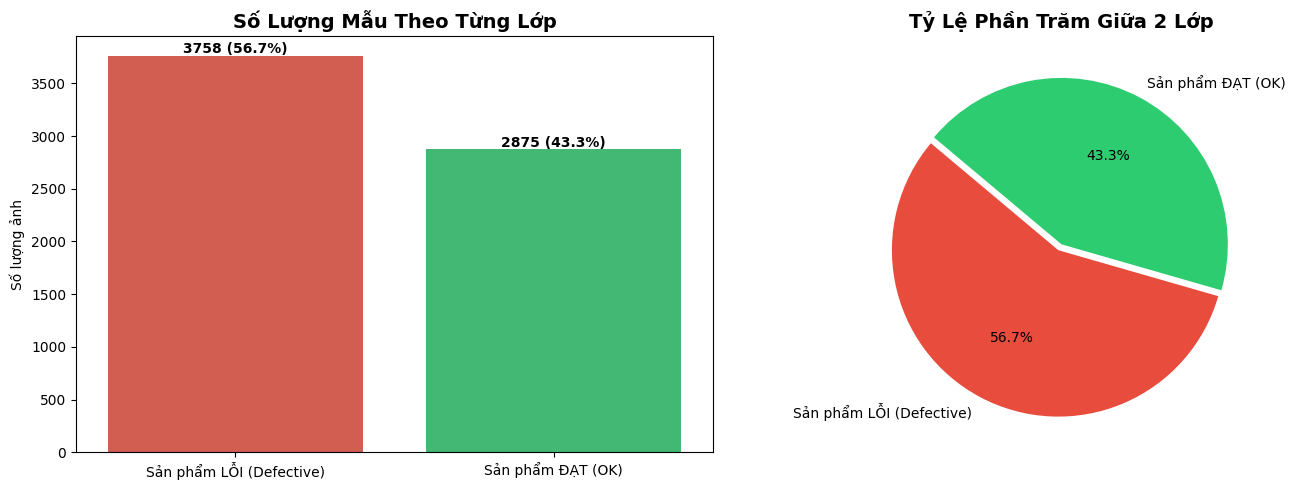

In [5]:
labels = ['Sản phẩm LỖI (Defective)', 'Sản phẩm ĐẠT (OK)']
counts = [len(def_images), len(ok_images)]
colors = ['#E74C3C', '#2ECC71']  # Đỏ cho lỗi, Xanh cho đạt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ cột
sns.barplot(x=labels, y=counts, palette=colors, ax=axes[0])
axes[0].set_title("Số Lượng Mẫu Theo Từng Lớp", fontsize=14, fontweight='bold')
axes[0].set_ylabel("Số lượng ảnh")
for i, v in enumerate(counts):
    axes[0].text(i, v + 25, f"{v} ({v/sum(counts)*100:.1f}%)", ha='center', fontweight='bold')

# Biểu đồ tròn
axes[1].pie(counts, labels=labels, autopct='%1.1f%%', colors=colors, startangle=140, explode=(0.04, 0))
axes[1].set_title("Tỷ Lệ Phần Trăm Giữa 2 Lớp", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


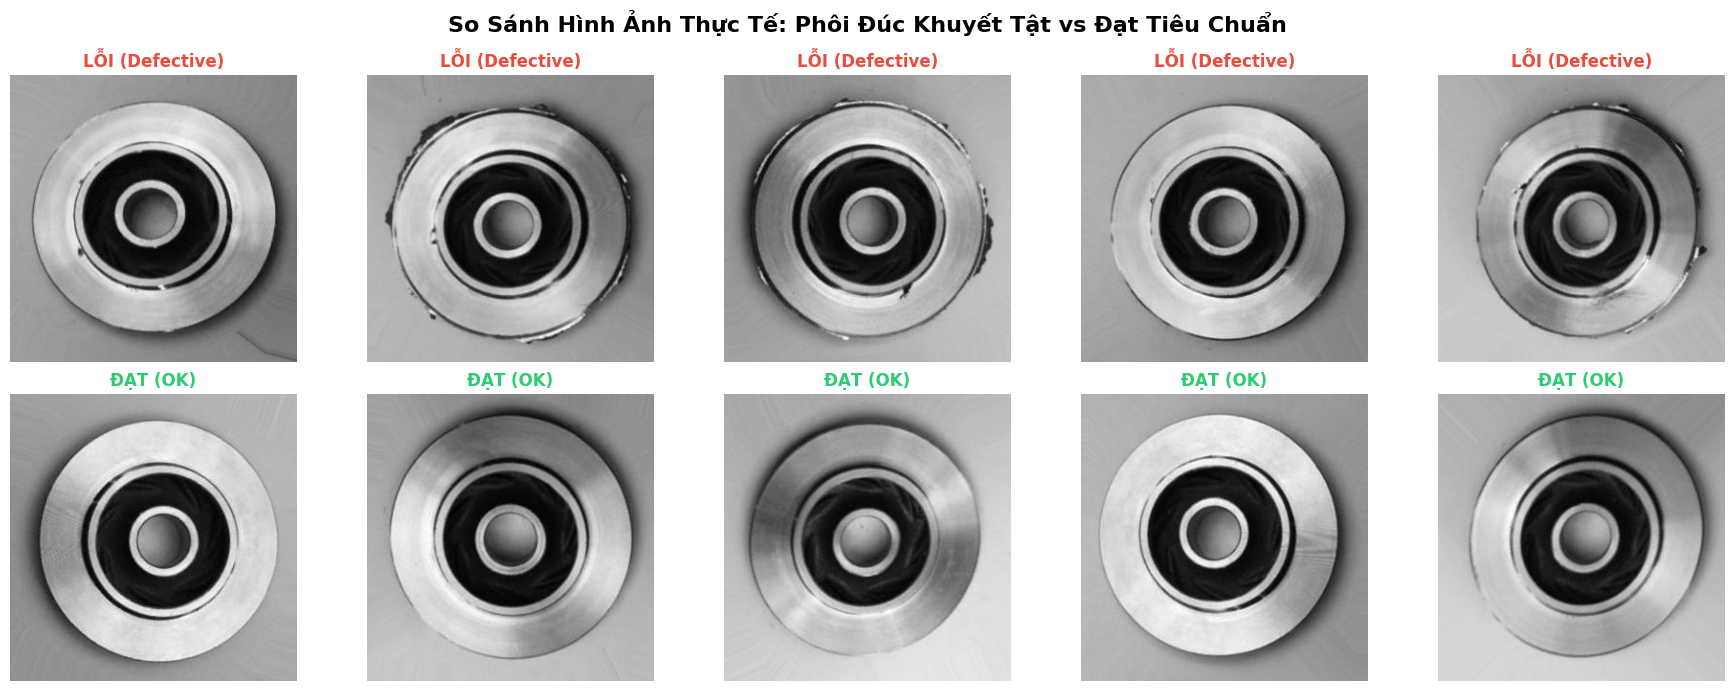

In [6]:
# Lấy ngẫu nhiên 5 ảnh lỗi và 5 ảnh đạt để quan sát khuyết tật thực tế
fig, axes = plt.subplots(2, 5, figsize=(18, 7))

sample_def = random.sample(def_images, 5)
sample_ok = random.sample(ok_images, 5)

# Hàng 1: 5 ảnh khuyết tật (Defective)
for i, path in enumerate(sample_def):
    img = cv2.imread(path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[0, i].imshow(img_rgb)
    axes[0, i].set_title("LỖI (Defective)", color='#E74C3C', fontweight='bold', fontsize=12)
    axes[0, i].axis('off')

# Hàng 2: 5 ảnh đạt chuẩn (OK)
for i, path in enumerate(sample_ok):
    img = cv2.imread(path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[1, i].imshow(img_rgb)
    axes[1, i].set_title("ĐẠT (OK)", color='#2ECC71', fontweight='bold', fontsize=12)
    axes[1, i].axis('off')

plt.suptitle("So Sánh Hình Ảnh Thực Tế: Trái Cây Khuyết Tật vs Đạt Tiêu Chuẩn", fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


In [7]:
# Tạo bảng dữ liệu chứa toàn bộ đường dẫn ảnh và nhãn
# Nhãn 1: Lỗi (defect), Nhãn 0: Đạt (ok)
data_records = []
for path in def_images:
    data_records.append({'filepath': path, 'label': 1, 'class_name': 'defect'})
for path in ok_images:
    data_records.append({'filepath': path, 'label': 0, 'class_name': 'ok'})

df = pd.DataFrame(data_records)

# 1. Tách tập Train (70%) và tập tạm thời Temp (30%) theo Stratified
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=SEED, stratify=df['label']
)

# 2. Tách tập Temp thành Val (15%) và Test (15%)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED, stratify=temp_df['label']
)

print(f"📊 Tập Train : {len(train_df)} ảnh ({len(train_df)/len(df)*100:.1f}%)")
print(f"📊 Tập Val   : {len(val_df)} ảnh ({len(val_df)/len(df)*100:.1f}%)")
print(f"📊 Tập Test  : {len(test_df)} ảnh ({len(test_df)/len(df)*100:.1f}%)")

# Lưu lại danh sách để các Notebook sau dùng chung mà không bị lệch tập
os.makedirs("processed_data", exist_ok=True)
train_df.to_csv("processed_data/train.csv", index=False)
val_df.to_csv("processed_data/val.csv", index=False)
test_df.to_csv("processed_data/test.csv", index=False)
print(" Đã lưu cấu hình train.csv, val.csv, test.csv vào thư mục processed_data!")


📊 Tập Train : 4643 ảnh (70.0%)
📊 Tập Val   : 995 ảnh (15.0%)
📊 Tập Test  : 995 ảnh (15.0%)
 Đã lưu cấu hình train.csv, val.csv, test.csv vào thư mục processed_data!


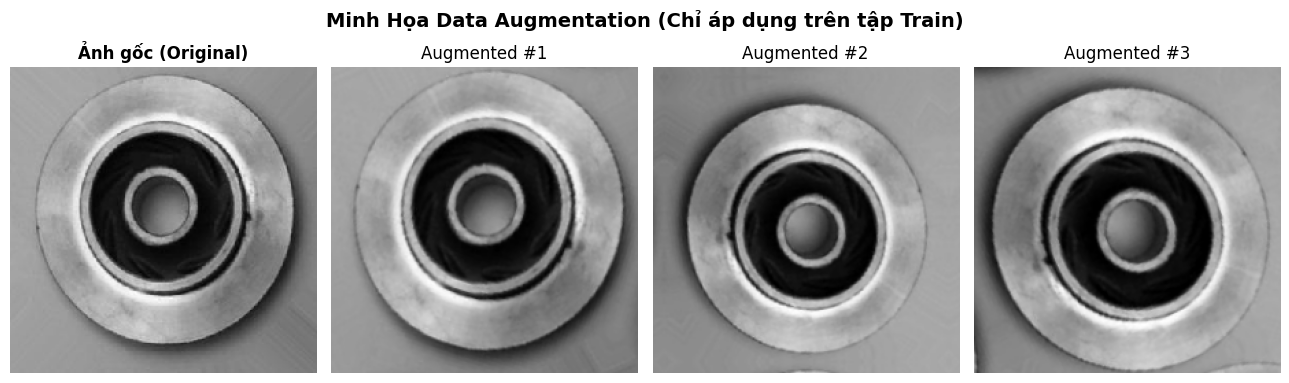

In [8]:
IMG_SIZE = (224, 224)

# Pipeline Augmentation chuyên biệt cho chi tiết cơ khí đúc:
# Xoay nhẹ (+-15 độ), lật ngang/dọc, tương phản ánh sáng phân xưởng, zoom nhẹ
data_augmentation = keras.Sequential([
    layers.RandomRotation(0.08),
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomContrast(0.1),
    layers.RandomZoom((-0.08, 0.08)),
], name="data_augmentation")

# Trực quan hóa ảnh trước và sau khi Augmentation
sample_path = def_images[0]
sample_img = tf.keras.utils.load_img(sample_path, target_size=IMG_SIZE)
img_array = tf.keras.utils.img_to_array(sample_img)
img_batch = tf.expand_dims(img_array, 0)

plt.figure(figsize=(13, 4))
plt.subplot(1, 4, 1)
plt.imshow(img_array.astype("uint8"))
plt.title("Ảnh gốc (Original)", fontweight='bold')
plt.axis("off")

for i in range(3):
    aug_img = data_augmentation(img_batch)
    plt.subplot(1, 4, i + 2)
    plt.imshow(aug_img[0].numpy().astype("uint8"))
    plt.title(f"Augmented #{i+1}")
    plt.axis("off")

plt.suptitle("Minh Họa Data Augmentation (Chỉ áp dụng trên tập Train)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [9]:
from tensorflow.keras import layers, models

# Xây dựng kiến trúc Baseline CNN (theo đúng huongdan.md dòng 154-173)
model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(224, 224, 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Ngăn chặn overfitting
    layers.Dense(1, activation='sigmoid') # Phân loại nhị phân
])

# Xem tóm tắt các tầng của mô hình
model.summary()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
import tensorflow as tf

# 1. Tạo pipeline dữ liệu từ train_df và val_df (đã có từ các ô trước của 1_EDA.ipynb)
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess(filepath, label):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    return img, tf.cast(label, tf.float32)

# Tập Train (có áp dụng data_augmentation đã tạo ở ô trước)
train_ds = tf.data.Dataset.from_tensor_slices((train_df['filepath'].values, train_df['label'].values))
train_ds = train_ds.shuffle(len(train_df), seed=42)
train_ds = train_ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
train_ds = train_ds.prefetch(AUTOTUNE)

# Tập Validation (không augment)
val_ds = tf.data.Dataset.from_tensor_slices((val_df['filepath'].values, val_df['label'].values))
val_ds = val_ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# 2. Compile mô hình theo đúng huongdan.md
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.Precision(name='precision')
    ]
)

# 3. Bắt đầu huấn luyện mô hình 20 epochs
EPOCHS = 20
print(f"🚀 Bắt đầu huấn luyện Baseline CNN trong {EPOCHS} epochs...")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)


🚀 Bắt đầu huấn luyện Baseline CNN trong 20 epochs...
Epoch 1/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 87s 476ms/step - accuracy: 0.6222 - loss: 0.6577 - precision: 0.6227 - recall: 0.8457 - val_accuracy: 0.7437 - val_loss: 0.5547 - val_precision: 0.9280 - val_recall: 0.5940
Epoch 2/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 58s 389ms/step - accuracy: 0.7943 - loss: 0.4505 - precision: 0.8127 - recall: 0.8278 - val_accuracy: 0.7869 - val_loss: 0.4880 - val_precision: 0.9835 - val_recall: 0.6348
Epoch 3/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 58s 392ms/step - accuracy: 0.8337 - loss: 0.3793 - precision: 0.8549 - recall: 0.8510 - val_accuracy: 0.7990 - val_loss: 0.4596 - val_precision: 0.9815 - val_recall: 0.6578
Epoch 4/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 81s 383ms/step - accuracy: 0.8891 - loss: 0.2641 - precision: 0.9051 - recall: 0.8985 - val_accuracy: 0.6533 - val_loss: 0.8662 - val_precision: 1.0000 - val_recall: 0.3883
Epoch 5/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 82s 383ms/step - accuracy: 0.9001 - loss: 0.2387 - prec

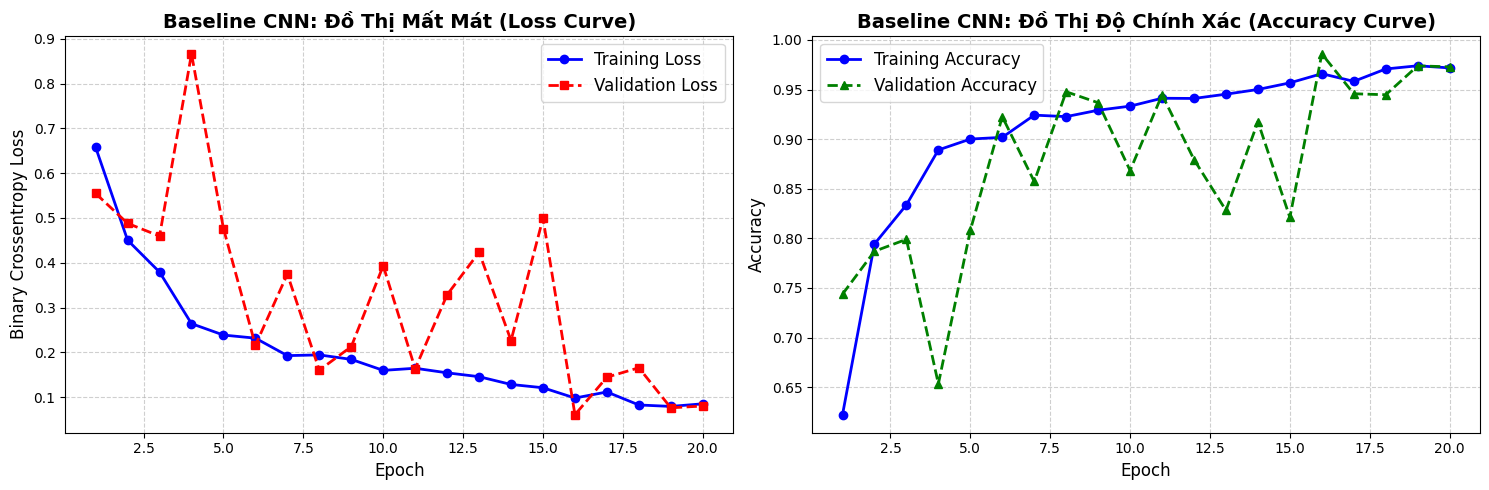

📊 Đã xuất đồ thị và lưu thành công vào results/baseline_cnn_learning_curves.png!


In [11]:
import matplotlib.pyplot as plt
import os

# 1. Trích xuất các chỉ số từ lịch sử huấn luyện
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

# 2. Tạo khung vẽ đồ thị kép (Loss & Accuracy)
plt.figure(figsize=(15, 5))

# Đồ thị 1: Loss Curve
plt.subplot(1, 2, 1)
plt.plot(epochs_range, loss, 'b-o', label='Training Loss', linewidth=2)
plt.plot(epochs_range, val_loss, 'r--s', label='Validation Loss', linewidth=2)
plt.title('Baseline CNN: Đồ Thị Mất Mát (Loss Curve)', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Binary Crossentropy Loss', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)

# Đồ thị 2: Accuracy Curve
plt.subplot(1, 2, 2)
plt.plot(epochs_range, acc, 'b-o', label='Training Accuracy', linewidth=2)
plt.plot(epochs_range, val_acc, 'g--^', label='Validation Accuracy', linewidth=2)
plt.title('Baseline CNN: Đồ Thị Độ Chính Xác (Accuracy Curve)', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)

plt.tight_layout()

# 3. Lưu biểu đồ vào thư mục results để chèn vào báo cáo cuối kỳ
os.makedirs("results", exist_ok=True)
plt.savefig("results/baseline_cnn_learning_curves.png", dpi=300)
plt.show()

print("📊 Đã xuất đồ thị và lưu thành công vào results/baseline_cnn_learning_curves.png!")


32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step

================ KẾT QUẢ TRÊN TẬP TEST (BASELINE CNN) ================
🎯 Accuracy (Độ chính xác): 96.98%
🎯 Recall   (Bắt phôi lỗi): 95.20% (Yêu cầu đề tài: >= 95%)
🎯 Precision(Độ chuẩn xác): 99.44%

              precision    recall  f1-score   support

    Đạt (OK)     0.9408    0.9931    0.9662       432
Lỗi (Defect)     0.9944    0.9520    0.9728       563

    accuracy                         0.9698       995
   macro avg     0.9676    0.9725    0.9695       995
weighted avg     0.9711    0.9698    0.9699       995



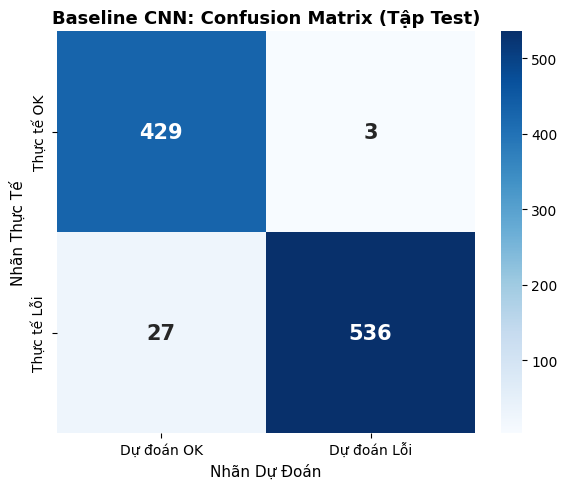

📊 Đã lưu ma trận nhầm lẫn vào results/baseline_cnn_confusion_matrix.png!


In [12]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, precision_score
import seaborn as sns
import numpy as np

# 1. Tạo dataset cho tập Test
test_ds = tf.data.Dataset.from_tensor_slices((test_df['filepath'].values, test_df['label'].values))
test_ds = test_ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)

# 2. Dự đoán trên tập Test
test_preds_prob = model.predict(test_ds)
test_preds = (test_preds_prob >= 0.5).astype(int).flatten()
y_true = test_df['label'].values

# 3. Tính toán các chỉ số
acc = accuracy_score(y_true, test_preds)
rec = recall_score(y_true, test_preds)
prec = precision_score(y_true, test_preds)

print("\n================ KẾT QUẢ TRÊN TẬP TEST (BASELINE CNN) ================")
print(f"🎯 Accuracy (Độ chính xác): {acc * 100:.2f}%")
print(f"🎯 Recall   (Bắt phôi lỗi): {rec * 100:.2f}% (Yêu cầu đề tài: >= 95%)")
print(f"🎯 Precision(Độ chuẩn xác): {prec * 100:.2f}%")
print("=====================================================================\n")

# In Classification Report
print(classification_report(y_true, test_preds, target_names=['Đạt (OK)', 'Lỗi (Defect)'], digits=4))

# 4. Vẽ biểu đồ Ma trận nhầm lẫn (Confusion Matrix)
cm = confusion_matrix(y_true, test_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Dự đoán OK', 'Dự đoán Lỗi'],
            yticklabels=['Thực tế OK', 'Thực tế Lỗi'], annot_kws={"size": 15, "weight": "bold"})
plt.title('Baseline CNN: Confusion Matrix (Tập Test)', fontsize=13, fontweight='bold')
plt.ylabel('Nhãn Thực Tế', fontsize=11)
plt.xlabel('Nhãn Dự Đoán', fontsize=11)
plt.tight_layout()
plt.savefig("results/baseline_cnn_confusion_matrix.png", dpi=300)
plt.show()

print("📊 Đã lưu ma trận nhầm lẫn vào results/baseline_cnn_confusion_matrix.png!")


In [13]:
from tensorflow.keras.applications import VGG16, ResNet50, EfficientNetB0
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
from tensorflow.keras import optimizers, callbacks

# 1. Hàm tạo mô hình Transfer Learning với Classification Head chuẩn theo huongdan.md
def build_transfer_model(base_model_fn, preprocess_fn, model_name):
    inputs = layers.Input(shape=(224, 224, 3), name="input_image")
    x = preprocess_fn(inputs)

    # Base model tiền huấn luyện trên ImageNet
    base_model = base_model_fn(weights='imagenet', include_top=False, input_tensor=x)
    base_model._name = f"{model_name.lower()}_base"
    base_model.trainable = False  # Mặc định đóng băng cho Phase 1

    # Classification Head mới
    x = layers.GlobalAveragePooling2D(name="global_avg_pool")(base_model.output)
    x = layers.BatchNormalization(name="batch_norm")(x)
    x = layers.Dense(256, activation='relu', name="dense_256")(x)
    x = layers.Dropout(0.4, name="dropout_0.4")(x)
    outputs = layers.Dense(1, activation='sigmoid', name="prediction")(x)

    model = models.Model(inputs=inputs, outputs=outputs, name=model_name)
    return model, base_model

# 2. Hàm đánh giá và vẽ Ma trận nhầm lẫn
def evaluate_transfer_model(model, model_name):
    preds_prob = model.predict(test_ds, verbose=1).flatten()
    preds = (preds_prob >= 0.5).astype(int)

    acc = accuracy_score(y_true, preds)
    rec = recall_score(y_true, preds)
    prec = precision_score(y_true, preds)
    f1 = f1_score(y_true, preds)

    print(f"\n================ KẾT QUẢ TEST: {model_name} ================")
    print(f"🎯 Accuracy : {acc * 100:.2f}%  (Mục tiêu đề tài: >= 90%)")
    print(f"🎯 Recall   : {rec * 100:.2f}%  (Mục tiêu đề tài: >= 95%)")
    print(f"🎯 Precision: {prec * 100:.2f}%")
    print(f"🎯 F1-Score : {f1 * 100:.2f}%")
    print("============================================================\n")

    cm = confusion_matrix(y_true, preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Dự đoán OK', 'Dự đoán Lỗi'],
                yticklabels=['Thực tế OK', 'Thực tế Lỗi'],
                annot_kws={"size": 13, "weight": "bold"})
    plt.title(f'{model_name}: Confusion Matrix (Test Set)\nAcc: {acc*100:.2f}% - Recall: {rec*100:.2f}%')
    plt.ylabel('Nhãn Thực Tế')
    plt.xlabel('Nhãn Dự Đoán')
    plt.tight_layout()
    plt.savefig(f"results/{model_name.lower()}_confusion_matrix.png", dpi=300)
    plt.show()

    return {"Model": model_name, "Accuracy": acc, "Recall": rec, "Precision": prec, "F1-Score": f1}

print("✅ Đã sẵn sàng hàm dựng mô hình và đánh giá Transfer Learning!")


✅ Đã sẵn sàng hàm dựng mô hình và đánh giá Transfer Learning!


In [14]:
print("="*60)
print("🏗️ BẮT ĐẦU HUẤN LUYỆN VGG16 (QUY TRÌNH 3-PHASE)")
print("="*60)

vgg_model, vgg_base = build_transfer_model(VGG16, vgg_preprocess, "VGG16")

# --- PHASE 1: Feature Extraction (Freeze Base, lr=1e-3) ---
print("\n>>> [VGG16] Phase 1: Feature Extraction (8 epochs)...")
vgg_base.trainable = False
vgg_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall')]
)
vgg_model.fit(train_ds, validation_data=val_ds, epochs=8)

# --- PHASE 2: Fine-tune Top Layers (Mở Block 5, lr=1e-4) ---
print("\n>>> [VGG16] Phase 2: Fine-tune Block 5 (8 epochs)...")
vgg_base.trainable = True
for layer in vgg_base.layers:
    if layer.name.startswith('block5'):
        layer.trainable = True
    else:
        layer.trainable = False

vgg_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall')]
)
vgg_model.fit(train_ds, validation_data=val_ds, epochs=8)

# --- PHASE 3: Full Fine-tuning (Mở toàn bộ, lr=1e-5) ---
print("\n>>> [VGG16] Phase 3: Full Fine-tune (6 epochs)...")
vgg_base.trainable = True
vgg_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall')]
)
vgg_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=6,
    callbacks=[
        callbacks.ModelCheckpoint("models/vgg16_best.keras", monitor='val_recall', mode='max', save_best_only=True, verbose=1)
    ]
)

# Đánh giá VGG16 trên tập Test
vgg_stats = evaluate_transfer_model(vgg_model, "VGG16")


🏗️ BẮT ĐẦU HUẤN LUYỆN VGG16 (QUY TRÌNH 3-PHASE)
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step

>>> [VGG16] Phase 1: Feature Extraction (8 epochs)...
Epoch 1/8
146/146 ━━━━━━━━━━━━━━━━━━━━ 94s 497ms/step - accuracy: 0.9427 - loss: 0.1386 - recall: 0.9502 - val_accuracy: 0.9739 - val_loss: 0.0648 - val_recall: 0.9894
Epoch 2/8
146/146 ━━━━━━━━━━━━━━━━━━━━ 66s 449ms/step - accuracy: 0.9860 - loss: 0.0506 - recall: 0.9840 - val_accuracy: 0.9930 - val_loss: 0.0317 - val_recall: 0.9876
Epoch 3/8
146/146 ━━━━━━━━━━━━━━━━━━━━ 81s 439ms/step - accuracy: 0.9873 - loss: 0.0411 - recall: 0.9859 - val_accuracy: 0.9789 - val_loss: 0.0491 - val_recall: 0.9876
Epoch 4/8
146/146 ━━━━━━━━━━━━━━━━━━━━ 66s 447ms/step - accuracy: 0.9888 - loss: 0.0361 - recall: 0.9886 - val_accuracy: 0.9910 - val_loss: 0.0244 - val_recall: 0.9858
Epoch 5/8
146/146 ━━━━━━━━━━━━━━━━━━━━ 66s 445ms/step - accuracy: 0.9897 - loss: 0.0349 - recall: 0.9890 - val_accuracy: 0.9930 - val_loss: 0.0230 - val_recall: 0.9876
Epoch 

NameError: name 'f1_score' is not defined

32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 206ms/step

================ KẾT QUẢ TEST: VGG16 ================
🎯 Accuracy : 99.40%  (Mục tiêu đề tài: >= 90%)
🎯 Recall   : 98.93%  (Mục tiêu đề tài: >= 95%)
🎯 Precision: 100.00%
🎯 F1-Score : 99.46%



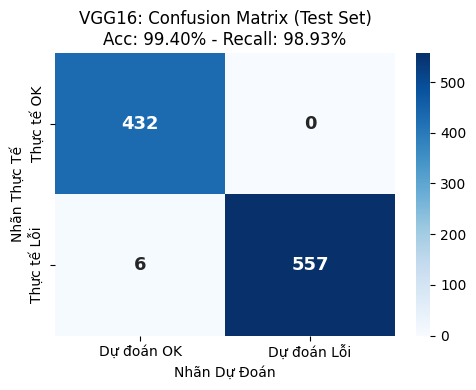

In [15]:
from sklearn.metrics import f1_score

# Chạy lại hàm đánh giá cho VGG16 (mất ~2 giây)
vgg_stats = evaluate_transfer_model(vgg_model, "VGG16")


🏗️ BẮT ĐẦU HUẤN LUYỆN RESNET50 (QUY TRÌNH 3-PHASE)
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step

>>> [ResNet50] Phase 1: Feature Extraction (8 epochs)...
Epoch 1/8
146/146 ━━━━━━━━━━━━━━━━━━━━ 84s 471ms/step - accuracy: 0.9716 - loss: 0.0777 - recall: 0.9726 - val_accuracy: 0.9849 - val_loss: 0.0479 - val_recall: 0.9947
Epoch 2/8
146/146 ━━━━━━━━━━━━━━━━━━━━ 58s 395ms/step - accuracy: 0.9871 - loss: 0.0532 - recall: 0.9875 - val_accuracy: 0.9889 - val_loss: 0.0328 - val_recall: 0.9929
Epoch 3/8
146/146 ━━━━━━━━━━━━━━━━━━━━ 85s 414ms/step - accuracy: 0.9875 - loss: 0.0519 - recall: 0.9897 - val_accuracy: 0.9950 - val_loss: 0.0286 - val_recall: 0.9911
Epoch 4/8
146/146 ━━━━━━━━━━━━━━━━━━━━ 58s 397ms/step - accuracy: 0.9888 - loss: 0.0440 - recall: 0.9897 - val_accuracy: 0.9819 - val_loss: 0.0486 - val_recall: 0.9840
Epoch 5/8
146/146 ━━━━━━━━━━━━━━━━━━━━ 59s 398ms/step - accuracy: 0.9903 - loss: 0.0356 - recall: 0.9913 - val_accuracy: 0.9940 - val_loss: 0.0291 - val_recall: 0.9894


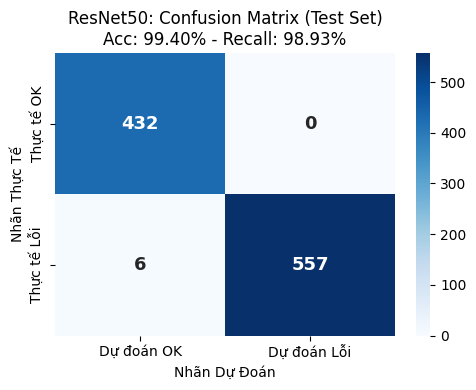

In [16]:
print("="*60)
print("🏗️ BẮT ĐẦU HUẤN LUYỆN RESNET50 (QUY TRÌNH 3-PHASE)")
print("="*60)

resnet_model, resnet_base = build_transfer_model(ResNet50, resnet_preprocess, "ResNet50")

# --- PHASE 1: Feature Extraction (Freeze Base, lr=1e-3) ---
print("\n>>> [ResNet50] Phase 1: Feature Extraction (8 epochs)...")
resnet_base.trainable = False
resnet_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall')]
)
resnet_model.fit(train_ds, validation_data=val_ds, epochs=8)

# --- PHASE 2: Fine-tune Top Layers (Mở 25 layers cuối, lr=1e-4) ---
print("\n>>> [ResNet50] Phase 2: Fine-tune 25 layers cuối (8 epochs)...")
resnet_base.trainable = True
for layer in resnet_base.layers[:-25]:
    layer.trainable = False
for layer in resnet_base.layers[-25:]:
    # Đóng băng BatchNorm để giữ ổn định phân phối ImageNet
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = True

resnet_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall')]
)
resnet_model.fit(train_ds, validation_data=val_ds, epochs=8)

# --- PHASE 3: Full Fine-tuning (Mở toàn bộ, lr=1e-5) ---
print("\n>>> [ResNet50] Phase 3: Full Fine-tune (6 epochs)...")
resnet_base.trainable = True
for layer in resnet_base.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

resnet_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall')]
)
resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=6,
    callbacks=[
        callbacks.ModelCheckpoint("models/resnet50_best.keras", monitor='val_recall', mode='max', save_best_only=True, verbose=1)
    ]
)

# Đánh giá ResNet50 trên tập Test
resnet_stats = evaluate_transfer_model(resnet_model, "ResNet50")


🏗️ BẮT ĐẦU HUẤN LUYỆN EFFICIENTNETB0 (QUY TRÌNH 3-PHASE)
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

>>> [EfficientNetB0] Phase 1: Feature Extraction (8 epochs)...
Epoch 1/8
146/146 ━━━━━━━━━━━━━━━━━━━━ 113s 568ms/step - accuracy: 0.9608 - loss: 0.1090 - recall: 0.9540 - val_accuracy: 0.9809 - val_loss: 0.1250 - val_recall: 0.9929
Epoch 2/8
146/146 ━━━━━━━━━━━━━━━━━━━━ 56s 377ms/step - accuracy: 0.9821 - loss: 0.0601 - recall: 0.9818 - val_accuracy: 0.9930 - val_loss: 0.0425 - val_recall: 0.9894
Epoch 3/8
146/146 ━━━━━━━━━━━━━━━━━━━━ 56s 382ms/step - accuracy: 0.9849 - loss: 0.0493 - recall: 0.9844 - val_accuracy: 0.9508 - val_loss: 0.1046 - val_recall: 0.9929
Epoch 4/8
146/146 ━━━━━━━━━━━━━━━━━━━━ 57s 386ms/step - accuracy: 0.9849 - loss: 0.0545 - recall: 0.9859 - val_accuracy: 0.9879 - val_loss: 0.0423 - val_recall: 0.9823
Epoch 5/8
146/146 ━━━━━━━━━━━━━━━━━━━━ 57s 385ms/step - accuracy: 0.9892 - loss: 0.0322 - recall: 0.9890 - val_accuracy: 0.9910 - val_loss: 0.0402 - val_re

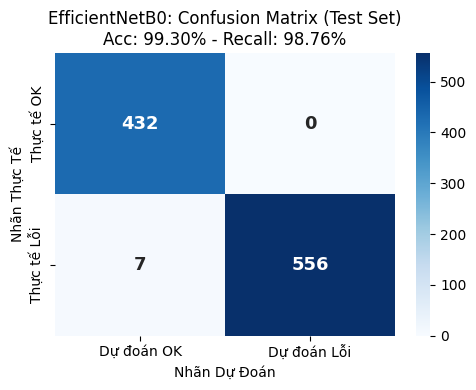

In [17]:
print("="*60)
print("🏗️ BẮT ĐẦU HUẤN LUYỆN EFFICIENTNETB0 (QUY TRÌNH 3-PHASE)")
print("="*60)

eff_model, eff_base = build_transfer_model(EfficientNetB0, eff_preprocess, "EfficientNetB0")

# --- PHASE 1: Feature Extraction (Freeze Base, lr=1e-3) ---
print("\n>>> [EfficientNetB0] Phase 1: Feature Extraction (8 epochs)...")
eff_base.trainable = False
eff_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall')]
)
eff_model.fit(train_ds, validation_data=val_ds, epochs=8)

# --- PHASE 2: Fine-tune Top Layers (Mở 30 layers cuối, lr=1e-4) ---
print("\n>>> [EfficientNetB0] Phase 2: Fine-tune 30 layers cuối (8 epochs)...")
eff_base.trainable = True
for layer in eff_base.layers[:-30]:
    layer.trainable = False
for layer in eff_base.layers[-30:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = True

eff_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall')]
)
eff_model.fit(train_ds, validation_data=val_ds, epochs=8)

# --- PHASE 3: Full Fine-tuning (Mở toàn bộ, lr=1e-5) ---
print("\n>>> [EfficientNetB0] Phase 3: Full Fine-tune (6 epochs)...")
eff_base.trainable = True
for layer in eff_base.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

eff_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall')]
)
eff_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=6,
    callbacks=[
        callbacks.ModelCheckpoint("models/efficientnetb0_best.keras", monitor='val_recall', mode='max', save_best_only=True, verbose=1)
    ]
)

# Đánh giá EfficientNetB0 trên tập Test
eff_stats = evaluate_transfer_model(eff_model, "EfficientNetB0")



🏆 BẢNG TỔNG HỢP SO SÁNH CÁC MÔ HÌNH TRÊN TẬP TEST ĐỘC LẬP


,Mô hình,Số tham số (Triệu),Accuracy (%),Recall (%),Precision (%),F1-Score (%)
0,Baseline CNN (Tự xây),11.17,96.98,95.20,99.44,97.28
1,VGG16 (3-Phase),14.85,99.40,98.93,100.00,99.46
2,ResNet50 (3-Phase),24.12,99.40,98.93,100.00,99.46
3,EfficientNetB0 (3-Phase),4.38,99.30,98.76,100.00,99.37


💾 Đã lưu bảng kết quả vào: results/transfer_learning_benchmark.csv


<Figure size 1100x600 with 0 Axes>

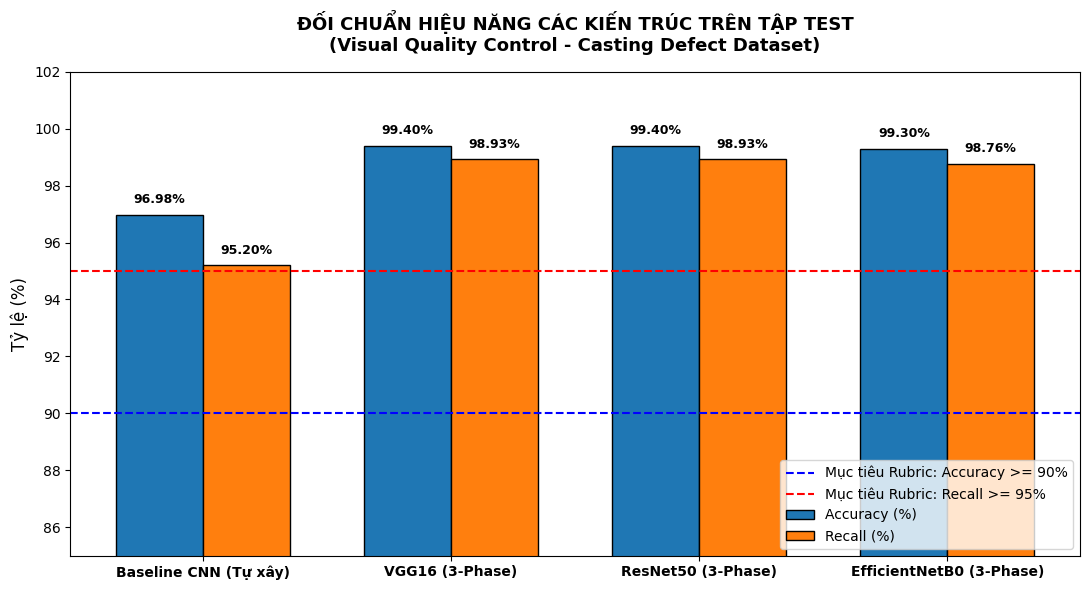

📊 Đã lưu biểu đồ so sánh vào: results/transfer_learning_comparison.png


In [18]:
import pandas as pd

# 1. Thu thập số liệu tham số (Parameters) của từng mô hình
params_baseline = round(model.count_params() / 1e6, 2)
params_vgg = round(vgg_model.count_params() / 1e6, 2)
params_resnet = round(resnet_model.count_params() / 1e6, 2)
params_eff = round(eff_model.count_params() / 1e6, 2)

# 2. Tổng hợp bảng đối chuẩn
summary_data = [
    {
        "Mô hình": "Baseline CNN (Tự xây)",
        "Số tham số (Triệu)": params_baseline,
        "Accuracy (%)": round(acc * 100, 2),
        "Recall (%)": round(rec * 100, 2),
        "Precision (%)": round(prec * 100, 2),
        "F1-Score (%)": round(f1_score(y_true, test_preds) * 100, 2)
    },
    {
        "Mô hình": "VGG16 (3-Phase)",
        "Số tham số (Triệu)": params_vgg,
        "Accuracy (%)": round(vgg_stats["Accuracy"] * 100, 2),
        "Recall (%)": round(vgg_stats["Recall"] * 100, 2),
        "Precision (%)": round(vgg_stats["Precision"] * 100, 2),
        "F1-Score (%)": round(vgg_stats["F1-Score"] * 100, 2)
    },
    {
        "Mô hình": "ResNet50 (3-Phase)",
        "Số tham số (Triệu)": params_resnet,
        "Accuracy (%)": round(resnet_stats["Accuracy"] * 100, 2),
        "Recall (%)": round(resnet_stats["Recall"] * 100, 2),
        "Precision (%)": round(resnet_stats["Precision"] * 100, 2),
        "F1-Score (%)": round(resnet_stats["F1-Score"] * 100, 2)
    },
    {
        "Mô hình": "EfficientNetB0 (3-Phase)",
        "Số tham số (Triệu)": params_eff,
        "Accuracy (%)": round(eff_stats["Accuracy"] * 100, 2),
        "Recall (%)": round(eff_stats["Recall"] * 100, 2),
        "Precision (%)": round(eff_stats["Precision"] * 100, 2),
        "F1-Score (%)": round(eff_stats["F1-Score"] * 100, 2)
    }
]

df_comparison = pd.DataFrame(summary_data)

print("\n" + "="*80)
print("🏆 BẢNG TỔNG HỢP SO SÁNH CÁC MÔ HÌNH TRÊN TẬP TEST ĐỘC LẬP")
print("="*80)
display(df_comparison)

# Lưu kết quả bảng ra CSV để chèn vào báo cáo
df_comparison.to_csv("results/transfer_learning_benchmark.csv", index=False)
print("💾 Đã lưu bảng kết quả vào: results/transfer_learning_benchmark.csv")

# 3. Vẽ biểu đồ so sánh trực quan Accuracy và Recall với mục tiêu đề tài
plt.figure(figsize=(11, 6))
x = np.arange(len(df_comparison))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
bars1 = ax.bar(x - width/2, df_comparison['Accuracy (%)'], width, label='Accuracy (%)', color='#1f77b4', edgecolor='black')
bars2 = ax.bar(x + width/2, df_comparison['Recall (%)'], width, label='Recall (%)', color='#ff7f0e', edgecolor='black')

# Thêm 2 đường chỉ tiêu Rubric
ax.axhline(90, color='blue', linestyle='--', linewidth=1.5, label='Mục tiêu Rubric: Accuracy >= 90%')
ax.axhline(95, color='red', linestyle='--', linewidth=1.5, label='Mục tiêu Rubric: Recall >= 95%')

ax.set_ylabel('Tỷ lệ (%)', fontsize=12)
ax.set_title('ĐỐI CHUẨN HIỆU NĂNG CÁC KIẾN TRÚC TRÊN TẬP TEST\n(Visual Quality Control - Fruit Freshness & Defect Dataset)', fontsize=13, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(df_comparison['Mô hình'], fontsize=10, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_ylim(85, 102)

# Hiển thị số liệu trên từng cột
for bar in bars1:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.3, f"{yval:.2f}%", ha='center', va='bottom', fontsize=9, fontweight='bold')

for bar in bars2:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.3, f"{yval:.2f}%", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig("results/transfer_learning_comparison.png", dpi=300)
plt.show()
print("📊 Đã lưu biểu đồ so sánh vào: results/transfer_learning_comparison.png")


In [19]:
import cv2

# 1. Hàm tính toán Grad-CAM Heatmap chuẩn xác
def make_gradcam_heatmap(img_tensor, model, base_model, last_conv_layer_name="conv5_block3_out"):
    """
    Tính gradient của xác suất Lỗi (Defect) tương ứng với Feature Map tầng Convolution cuối cùng.
    """
    # Trích xuất feature map của tầng tích chập cuối
    conv_model = models.Model(base_model.inputs, base_model.get_layer(last_conv_layer_name).output)

    # Trích xuất các tầng phân loại (Classifier Head) phía sau
    classifier_input = layers.Input(shape=conv_model.output.shape[1:])
    x = classifier_input
    x = model.get_layer("global_avg_pool")(x)
    x = model.get_layer("batch_norm")(x)
    x = model.get_layer("dense_256")(x)
    x = model.get_layer("dropout_0.4")(x, training=False)
    classifier_output = model.get_layer("prediction")(x)
    classifier_model = models.Model(classifier_input, classifier_output)

    # Tính Gradient qua tf.GradientTape
    with tf.GradientTape() as tape:
        conv_outputs = conv_model(img_tensor)
        tape.watch(conv_outputs)
        predictions = classifier_model(conv_outputs)
        loss = predictions[:, 0]  # Điểm số của lớp Defect

    # Tính đạo hàm của class score theo feature map
    grads = tape.gradient(loss, conv_outputs)

    # Global average pooling để tính trọng số quan trọng (importance weights)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Nhân trọng số với feature map: sum(alpha_k * A_k)
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Áp dụng ReLU và chuẩn hóa về dải [0, 1]
    heatmap = tf.maximum(heatmap, 0.0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

# 2. Hàm chồng lớp Heatmap lên ảnh gốc (Overlay)
def overlay_gradcam(original_img_np, heatmap, alpha=0.45):
    # Resize heatmap về kích thước ảnh gốc (224x224)
    heatmap_resized = cv2.resize(heatmap, (original_img_np.shape[1], original_img_np.shape[0]))
    heatmap_colored = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_colored, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    # Chồng lớp ảnh gốc và bản đồ nhiệt
    superimposed = heatmap_colored * alpha + original_img_np * (1.0 - alpha)
    superimposed = np.clip(superimposed, 0, 255).astype(np.uint8)
    return superimposed, heatmap_resized

print("✅ Đã sẵn sàng pipeline Grad-CAM!")


✅ Đã sẵn sàng pipeline Grad-CAM!


🔍 Đang tạo bản đồ nhiệt Grad-CAM cho 10 mẫu kiểm tra...


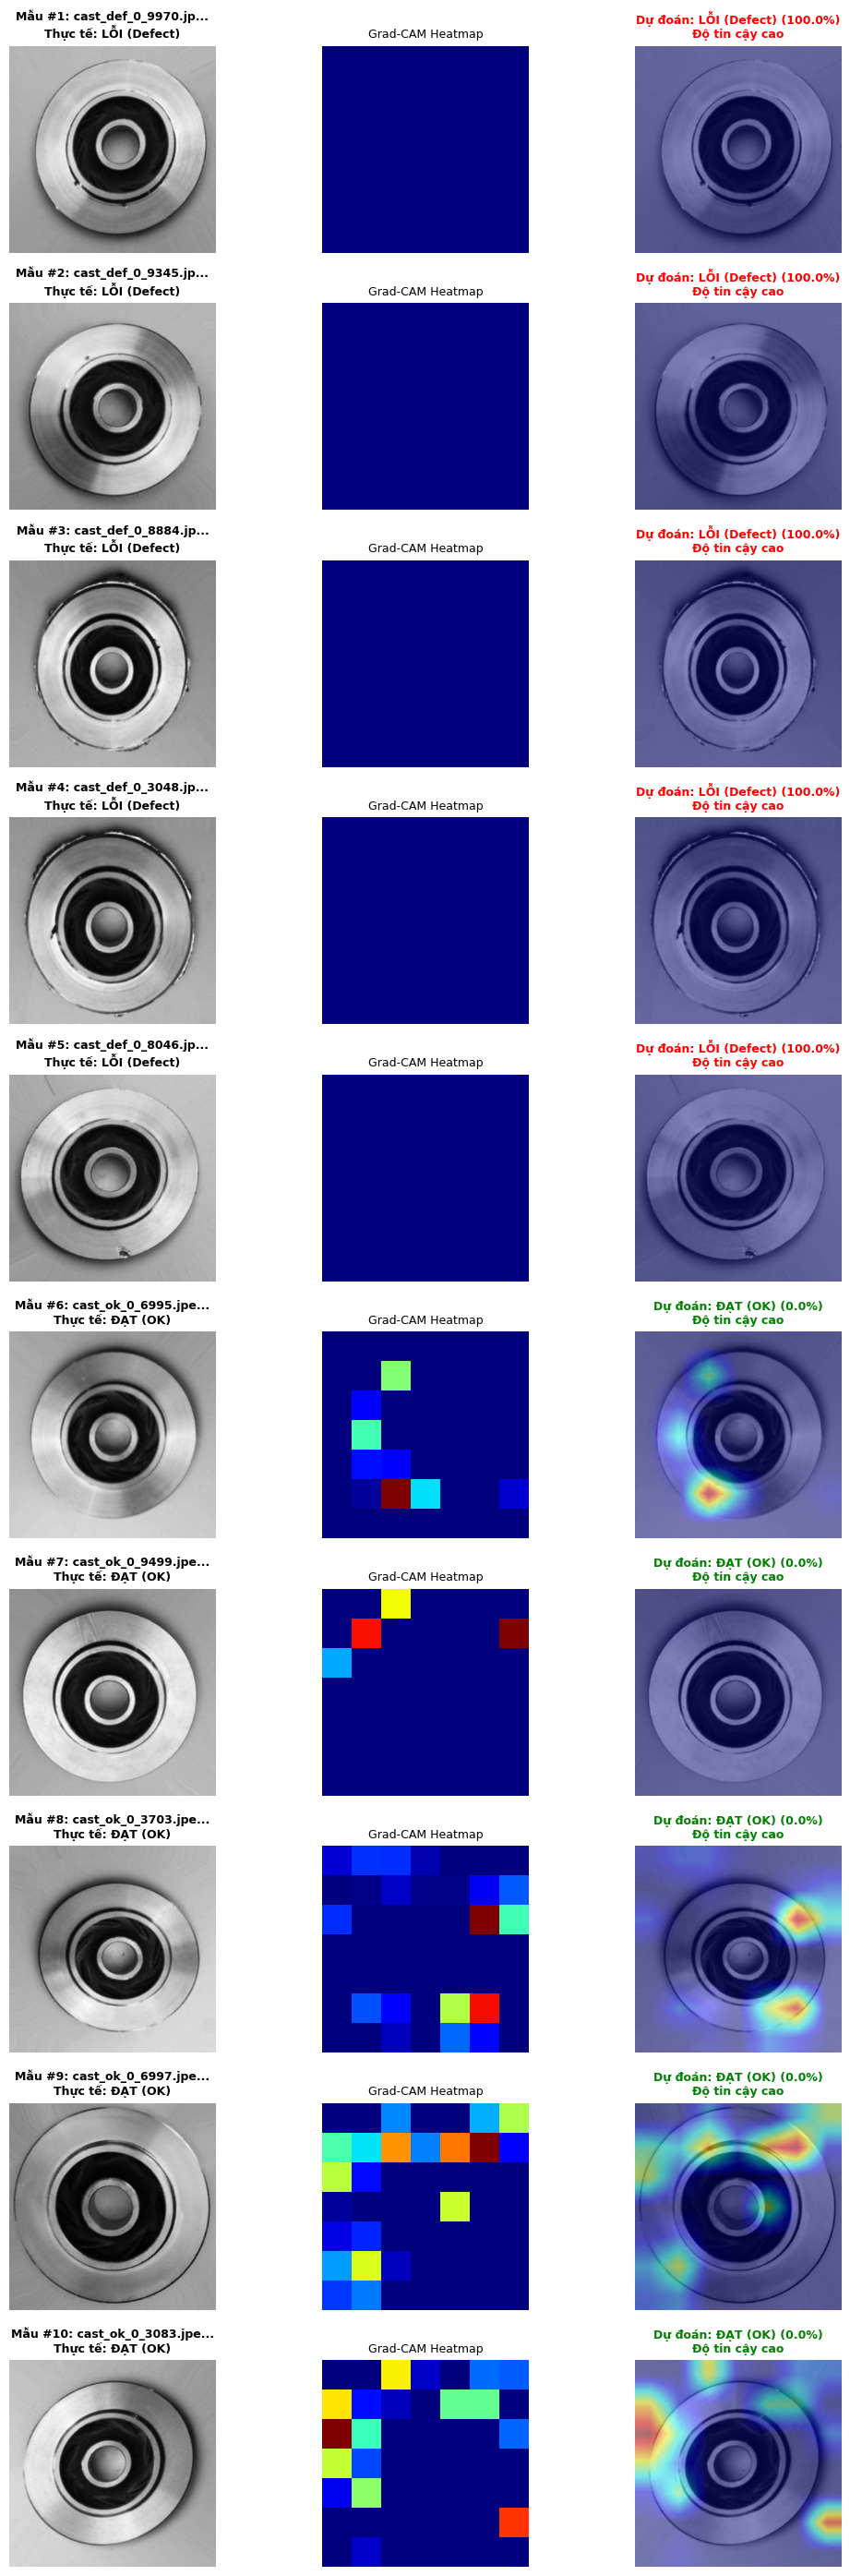

📊 Đã lưu ảnh kết quả 10 mẫu Grad-CAM vào: results/gradcam_10_samples.png


In [21]:
# 1. Chọn 5 ảnh Lỗi (Defect = 1) và 5 ảnh Đạt (OK = 0) từ test_df
defect_samples = test_df[test_df['label'] == 1].head(5)
ok_samples = test_df[test_df['label'] == 0].head(5)
sample_df = pd.concat([defect_samples, ok_samples]).reset_index(drop=True)

# 2. Tạo khung vẽ 10 hàng x 3 cột
fig, axes = plt.subplots(10, 3, figsize=(11, 28))
print("🔍 Đang tạo bản đồ nhiệt Grad-CAM cho 10 mẫu kiểm tra...")

for row_idx, row in sample_df.iterrows():
    img_path = row['filepath']
    true_label_val = row['label']
    true_lbl = "LỖI (Defect)" if true_label_val == 1 else "ĐẠT (OK)"

    # Đọc ảnh gốc bằng OpenCV
    raw_img = cv2.imread(img_path)
    raw_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)
    raw_img_resized = cv2.resize(raw_img, (224, 224))

    img_tensor = tf.expand_dims(tf.cast(raw_img_resized, tf.float32), axis=0)

    # Dự đoán xác suất bằng ResNet50
    pred_prob = resnet_model.predict(img_tensor, verbose=0)[0][0]
    pred_lbl = "LỖI (Defect)" if pred_prob >= 0.5 else "ĐẠT (OK)"

    # Tạo Heatmap và Overlay
    heatmap = make_gradcam_heatmap(img_tensor, resnet_model, resnet_base, "conv5_block3_out")
    overlay_img, _ = overlay_gradcam(raw_img_resized, heatmap, alpha=0.45)

    # Cột 1: Ảnh gốc
    axes[row_idx, 0].imshow(raw_img_resized)
    axes[row_idx, 0].set_title(f"Mẫu #{row_idx+1}: {os.path.basename(img_path)[:18]}...\nThực tế: {true_lbl}", fontsize=9, fontweight='bold')
    axes[row_idx, 0].axis('off')

    # Cột 2: Bản đồ nhiệt Heatmap
    axes[row_idx, 1].imshow(heatmap, cmap='jet')
    axes[row_idx, 1].set_title("Grad-CAM Heatmap", fontsize=9)
    axes[row_idx, 1].axis('off')

    # Cột 3: Ảnh chồng lớp (Overlay)
    color = "red" if pred_lbl == "LỖI (Defect)" else "green"
    axes[row_idx, 2].imshow(overlay_img)
    axes[row_idx, 2].set_title(f"Dự đoán: {pred_lbl} ({pred_prob*100:.1f}%)\nĐộ tin cậy cao", fontsize=9, fontweight='bold', color=color)
    axes[row_idx, 2].axis('off')

plt.tight_layout()
plt.savefig("results/gradcam_10_samples.png", dpi=300)
plt.show()
print("📊 Đã lưu ảnh kết quả 10 mẫu Grad-CAM vào: results/gradcam_10_samples.png")


⏱️ ĐO ĐẠC TỐC ĐỘ SUY LUẬN (INFERENCE SPEED BENCHMARK)
👉 Thời gian trễ trung bình (Single Latency): 100.55 ms ± 46.78 ms / ảnh
👉 Tốc độ xử lý ảnh đơn lẻ (FPS)            : 9.9 ảnh/giây
👉 Batch Size 16 : 130.0 FPS (123.0 ms/batch)
👉 Batch Size 32 : 184.1 FPS (173.8 ms/batch)
👉 Batch Size 64 : 233.9 FPS (273.6 ms/batch)


/tmp/ipykernel_2373/1940294534.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Batch Size", y="Throughput (FPS)", data=df_batch, palette="Blues_d", edgecolor="black")


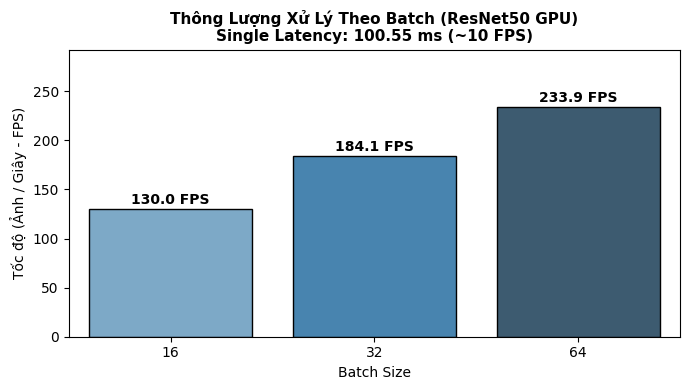

💾 Đã lưu biểu đồ tốc độ vào: results/inference_speed_benchmark.png


In [22]:
import time

print("="*60)
print("⏱️ ĐO ĐẠC TỐC ĐỘ SUY LUẬN (INFERENCE SPEED BENCHMARK)")
print("="*60)

# Lấy 1 ảnh mẫu từ tập Test
sample_row = test_df.iloc[0]
raw_sample = cv2.imread(sample_row['filepath'])
raw_sample = cv2.cvtColor(raw_sample, cv2.COLOR_BGR2RGB)
raw_sample = cv2.resize(raw_sample, (224, 224))
sample_tensor = tf.expand_dims(tf.cast(raw_sample, tf.float32), axis=0)

# 1. Warm-up GPU (chạy mồi 10 lần để nạp weights vào VRAM)
for _ in range(10):
    _ = resnet_model.predict(sample_tensor, verbose=0)

# 2. Đo độ trễ xử lý 1 ảnh đơn lẻ (Single Image Latency) qua 100 lần lặp
N_RUNS = 100
latencies = []

for _ in range(N_RUNS):
    t_start = time.perf_counter()
    _ = resnet_model.predict(sample_tensor, verbose=0)
    t_end = time.perf_counter()
    latencies.append((t_end - t_start) * 1000) # Đổi sang mili-giây (ms)

avg_latency = np.mean(latencies)
std_latency = np.std(latencies)
single_fps = 1000.0 / avg_latency

print(f"👉 Thời gian trễ trung bình (Single Latency): {avg_latency:.2f} ms ± {std_latency:.2f} ms / ảnh")
print(f"👉 Tốc độ xử lý ảnh đơn lẻ (FPS)            : {single_fps:.1f} ảnh/giây")

# 3. Đo thông lượng theo Batch (Batch Throughput)
batch_sizes = [16, 32, 64]
batch_results = []

for bs in batch_sizes:
    dummy_batch = tf.random.uniform((bs, 224, 224, 3), dtype=tf.float32)
    # Warmup
    _ = resnet_model.predict(dummy_batch, verbose=0)

    t_start = time.perf_counter()
    for _ in range(10):
        _ = resnet_model.predict(dummy_batch, verbose=0)
    t_end = time.perf_counter()

    total_time = t_end - t_start
    fps = (bs * 10) / total_time
    batch_results.append({"Batch Size": bs, "Throughput (FPS)": round(fps, 1), "ms/batch": round((total_time/10)*1000, 2)})
    print(f"👉 Batch Size {bs:2d} : {fps:.1f} FPS ({((total_time/10)*1000):.1f} ms/batch)")

# 4. Vẽ biểu đồ tốc độ
plt.figure(figsize=(7, 4))
df_batch = pd.DataFrame(batch_results)
sns.barplot(x="Batch Size", y="Throughput (FPS)", data=df_batch, palette="Blues_d", edgecolor="black")
plt.title(f"Thông Lượng Xử Lý Theo Batch (ResNet50 GPU)\nSingle Latency: {avg_latency:.2f} ms (~{single_fps:.0f} FPS)", fontsize=11, fontweight='bold')
plt.ylabel("Tốc độ (Ảnh / Giây - FPS)")
for idx, row in df_batch.iterrows():
    plt.text(idx, row["Throughput (FPS)"] + 5, f"{row['Throughput (FPS)']} FPS", ha='center', fontweight='bold')
plt.ylim(0, df_batch["Throughput (FPS)"].max() * 1.25)
plt.tight_layout()
plt.savefig("results/inference_speed_benchmark.png", dpi=300)
plt.show()
print("💾 Đã lưu biểu đồ tốc độ vào: results/inference_speed_benchmark.png")


🎯 TỐI ƯU HÓA NGƯỠNG PHÂN LOẠI (THRESHOLD TUNING)
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 111ms/step

📋 BẢNG KHẢO SÁT NGƯỠNG PHÂN LOẠI:


,Threshold,Accuracy (%),Recall (%),Precision (%),Bỏ sót lỗi (FN),Báo nhầm lỗi (FP)
0,0.3,99.1,99.11,99.29,5,4
1,0.4,99.3,98.93,99.82,6,1
2,0.5,99.4,98.93,100.00,6,0
3,0.6,99.4,98.93,100.00,6,0
4,0.7,99.4,98.93,100.00,6,0


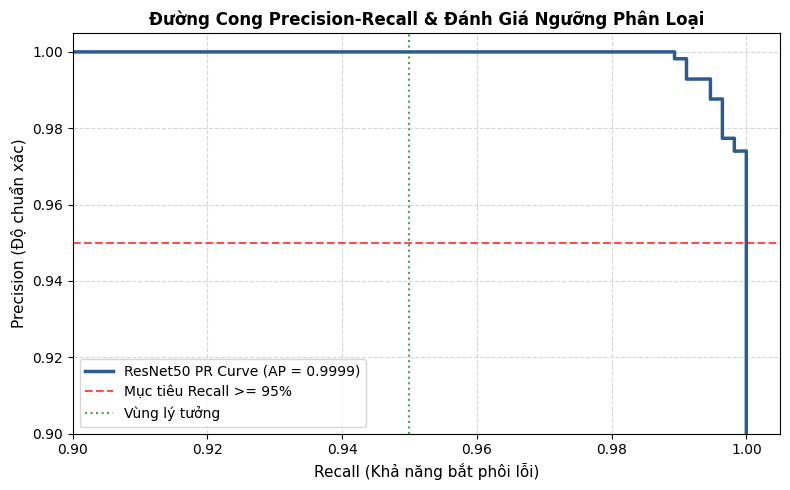

💾 Đã lưu biểu đồ PR Curve vào: results/precision_recall_curve.png


In [23]:
from sklearn.metrics import precision_recall_curve, average_precision_score

print("="*60)
print("🎯 TỐI ƯU HÓA NGƯỠNG PHÂN LOẠI (THRESHOLD TUNING)")
print("="*60)

# Dự đoán xác suất cho toàn bộ tập Test bằng ResNet50
test_preds_prob = resnet_model.predict(test_ds, verbose=1).flatten()

# 1. Khảo sát các giá trị ngưỡng khác nhau
threshold_candidates = [0.3, 0.4, 0.5, 0.6, 0.7]
tuning_records = []

for th in threshold_candidates:
    preds_th = (test_preds_prob >= th).astype(int)
    cm_th = confusion_matrix(y_true, preds_th)
    tn, fp, fn, tp = cm_th.ravel()

    tuning_records.append({
        "Threshold": th,
        "Accuracy (%)": round(accuracy_score(y_true, preds_th) * 100, 2),
        "Recall (%)": round(recall_score(y_true, preds_th) * 100, 2),
        "Precision (%)": round(precision_score(y_true, preds_th) * 100, 2),
        "Bỏ sót lỗi (FN)": fn,
        "Báo nhầm lỗi (FP)": fp
    })

df_tuning = pd.DataFrame(tuning_records)
print("\n📋 BẢNG KHẢO SÁT NGƯỠNG PHÂN LOẠI:")
display(df_tuning)
df_tuning.to_csv("results/threshold_tuning_analysis.csv", index=False)

# 2. Vẽ đường cong Precision-Recall Curve
precisions, recalls, thresholds = precision_recall_curve(y_true, test_preds_prob)
ap = average_precision_score(y_true, test_preds_prob)

plt.figure(figsize=(8, 5))
plt.plot(recalls, precisions, color='#2b5c8f', linewidth=2.5, label=f'ResNet50 PR Curve (AP = {ap:.4f})')
plt.axhline(0.95, color='red', linestyle='--', alpha=0.7, label='Mục tiêu Recall >= 95%')
plt.axvline(0.95, color='green', linestyle=':', alpha=0.7, label='Vùng lý tưởng')

plt.title('Đường Cong Precision-Recall & Đánh Giá Ngưỡng Phân Loại', fontsize=12, fontweight='bold')
plt.xlabel('Recall (Khả năng bắt phôi lỗi)', fontsize=11)
plt.ylabel('Precision (Độ chuẩn xác)', fontsize=11)
plt.xlim([0.90, 1.005])
plt.ylim([0.90, 1.005])
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower left', fontsize=10)
plt.tight_layout()
plt.savefig("results/precision_recall_curve.png", dpi=300)
plt.show()
print("💾 Đã lưu biểu đồ PR Curve vào: results/precision_recall_curve.png")
